## 1. 环境准备

导入必要的库并配置中文字体支持。

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib import rcParams

# ================== 全局环境配置 ==================
# 配置 matplotlib 使用中文字体
# 注意：run_jupyterlab.sh 已通过挂载 matplotlibrc 文件进行全局配置
# 这里再次配置是为了确保在非 Docker 环境（如本地直接运行）下也能正确显示中文
def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows标准/Docker挂载
        # Heiti TC: Mac标准
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        rcParams['font.sans-serif'] = fonts
        rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    except:
        pass

config_fonts()
print("环境配置完成，中文字体已设置。")

环境配置完成，中文字体已设置。


## 2. KNN 模型构建与评估

本部分演示 K-近邻 (KNN) 算法在鸢尾花分类问题中的应用：
1.  **数据加载与探索**：加载鸢尾花数据集，并使用散点图矩阵可视化特征分布。
2.  **数据预处理**：按 7:3 划分训练集和测试集（分层抽样），并对特征进行标准化处理（KNN 对尺度敏感）。
3.  **模型训练**：构建 KNN 分类器（K=3）并拟合训练数据。
4.  **模型评估**：在测试集上进行预测，计算准确率、混淆矩阵并生成分类报告。

特征名称： ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
目标类别： ['setosa' 'versicolor' 'virginica']
数据集大小： (150, 4)


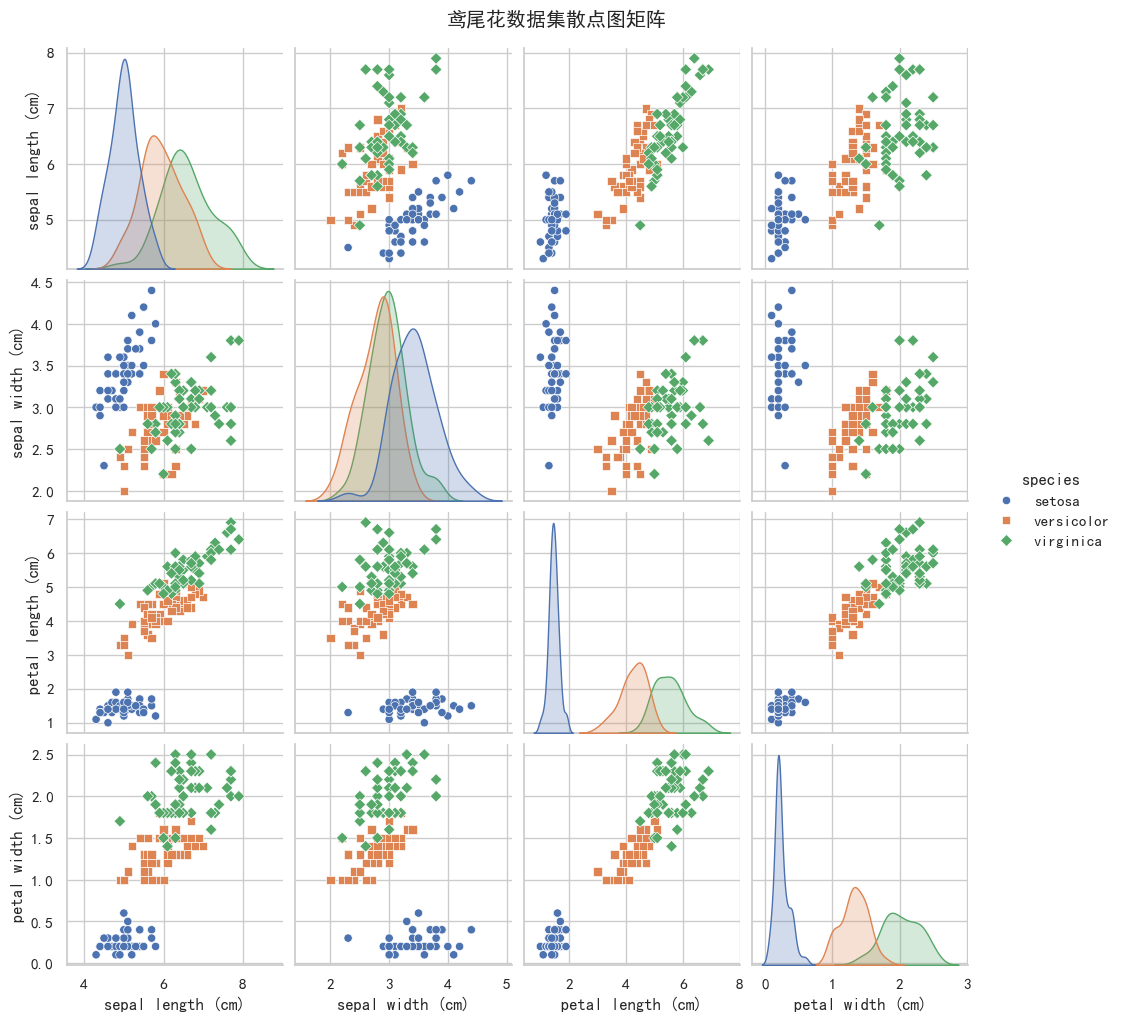


训练集特征均值： [ 2.38327876e-15 -1.12145742e-15 -1.37456184e-16 -6.97854473e-17]

训练集特征标准差： [1. 1. 1. 1.]
模型准确率：91.11%

混淆矩阵：
 [[15  0  0]
 [ 0 15  0]
 [ 0  4 11]]

分类报告：
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



In [28]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 加载鸢尾花数据集
data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print("特征名称：", feature_names)
print("目标类别：", target_names)
print("数据集大小：", X.shape)

# 可视化数据分布
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
sns.pairplot(df, hue='species', markers=["o", "s", "D"])
plt.suptitle("鸢尾花数据集散点图矩阵", y=1.02)
plt.show()

# 切分数据集为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 特征标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\n训练集特征均值：", X_train.mean(axis=0))
print("\n训练集特征标准差：", X_train.std(axis=0))
# 创建KNN模型，选择K=3
knn = KNeighborsClassifier(n_neighbors=3)

# 训练模型
knn.fit(X_train, y_train)

# 进行预测
y_pred = knn.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率：{accuracy * 100:.2f}%")

# 混淆矩阵
conf_matrix = confusion_matrix(y_test, y_pred)

# 分类报告
class_report = classification_report(y_test, y_pred, target_names=target_names)

print("\n混淆矩阵：\n", conf_matrix)
print("\n分类报告：\n", class_report)

### 2.1 模型性能总结

1. **训练集特征均值**：
   ```
   [ 2.38327876e-15 -1.12145742e-15 -1.37456184e-16 -6.97854473e-17]
   ```
   这些值非常接近于0，说明特征已经被标准化，均值接近0。

2. **训练集特征标准差**：
   ```
   [1. 1. 1. 1.]
   ```
   标准差为1，说明特征已经被标准化，每个特征的标准差都是1。

3. **模型准确率**：
   ```
   91.11%
   ```
   模型在测试集上的准确率为91.11%，表现良好。

4. **混淆矩阵**：
   ```
   [[15  0  0]
    [ 0 15  0]
    [ 0  4 11]]
   ```
   - 第一行：15个 setosa 样本全部被正确分类。
   - 第二行：15个 versicolor 样本全部被正确分类。
   - 第三行：15个 virginica 样本中有 4 个被错误分类为 versicolor ，11个被正确分类。

5. **分类报告**：
   ```
                   precision    recall  f1-score   support
    
          setosa       1.00      1.00      1.00        15
      versicolor       0.79      1.00      0.88        15
       virginica       1.00      0.73      0.85        15
    
        accuracy                           0.91        45
       macro avg       0.93      0.91      0.91        45
    weighted avg       0.93      0.91      0.91        45
   ```

   - **setosa**：精确率和召回率均为1.00，说明所有setosa样本都被正确分类。
   - **versicolor**：精确率为0.79，召回率为1.00，说明所有versicolor样本都被正确分类，但有部分其他类别的样本被错误分类为versicolor。
   - **virginica**：精确率为1.00，召回率为0.73，说明部分virginica样本被错误分类为其他类别。

### 2.2 后续工作

1. **调整K值**：尝试不同的K值，找到最优的K值。可以通过交叉验证来选择最佳的K值。
2. **特征选择**：检查哪些特征对分类贡献最大，是否可以剔除一些特征。
3. **数据可视化**：进一步可视化数据，看看是否有明显的聚类或分离趋势，帮助理解模型的分类行为。

## 3. 决策边界可视化

本部分通过可视化决策边界来直观展示 KNN 模型的分类效果：
1.  **特征选择**：仅选取前两个特征（花萼长度和花萼宽度）以便在二维平面绘图。
2.  **数据准备**：重新划分数据并进行标准化，保持与模型训练一致的处理流程。
3.  **网格预测**：生成特征平面的网格点，预测每个点的类别以形成分类区域。
4.  **结果展示**：绘制决策边界颜色区域及训练样本散点图。

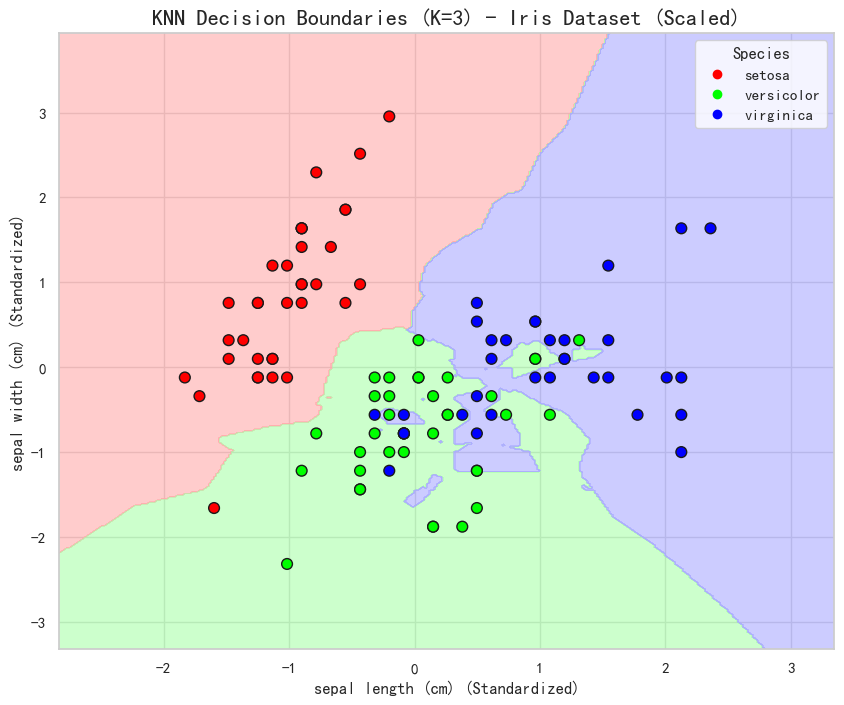

In [29]:
# 可视化决策边界
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap

# 设置绘图风格
sns.set(style="whitegrid")
config_fonts()

# 1. 加载数据
iris = load_iris()
# 为了便于二维可视化，我们只取前两个特征：sepal length (cm), sepal width (cm)
X = iris.data[:, :2]
y = iris.target
target_names = iris.target_names
feature_names = iris.feature_names[:2]

# 2. 数据集划分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. 特征标准化
# KNN 对尺度敏感，必须标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. 训练模型
# 使用 K=3 (根据文中案例推导或常见经验)
k = 3
clf = KNeighborsClassifier(n_neighbors=k)
clf.fit(X_train_scaled, y_train)

# 5. 绘制决策边界
# 创建网格
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
h = 0.02  # 网格步长
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 预测网格中每个点的类别
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 自定义颜色映射
# 浅色背景区域
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
# 深色散点
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.figure(figsize=(10, 8))

# 绘制区域背景
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)

# 绘制训练集数据点
scatter = plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, 
            cmap=cmap_bold, edgecolor='k', s=60, label='Training Data')

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

# 添加图例
# 创建自定义图例句柄
handles, _ = scatter.legend_elements()
legend_labels = target_names
plt.legend(handles, legend_labels, title="Species", loc="upper right")

plt.title(f"KNN Decision Boundaries (K={k}) - Iris Dataset (Scaled)", fontsize=16)
plt.xlabel(f"{feature_names[0]} (Standardized)", fontsize=12)
plt.ylabel(f"{feature_names[1]} (Standardized)", fontsize=12)

plt.show()

## 4. 进阶：动态 K 值选择

K 值的选择对模型性能有很大影响。K 值过小容易过拟合（对噪声敏感），K 值过大容易欠拟合（边界平滑）。
我们可以通过遍历不同的 K 值，观察其在测试集上的表现，来选择最优的 K。

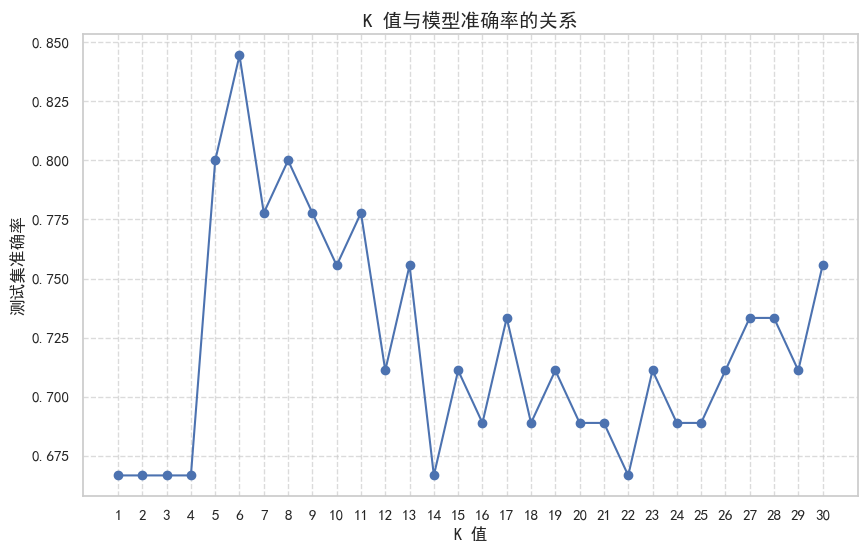

最优 K 值: 6, 最高准确率: 84.44%


In [30]:
# 寻找最优 K 值
k_range = range(1, 31)
scores = []

for k in k_range:
    # 使用之前划分好的标准化数据
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

# 绘制 K 值与准确率的关系图
plt.figure(figsize=(10, 6))
plt.plot(k_range, scores, marker='o', linestyle='-')
plt.title('K 值与模型准确率的关系', fontsize=14)
plt.xlabel('K 值', fontsize=12)
plt.ylabel('测试集准确率', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(k_range)
plt.show()

# 输出最优 K 值
best_k = k_range[np.argmax(scores)]
best_score = max(scores)
print(f"最优 K 值: {best_k}, 最高准确率: {best_score:.2%}")

## 5. 进阶：维度灾难与降维 (PCA)

在高维空间中，距离度量（如欧氏距离）可能会失效，导致 KNN 性能下降（维度灾难）。
主成分分析 (PCA) 是一种常用的降维技术，可以在保留大部分数据信息（方差）的同时降低维度。

原始特征维度: 4
降维后特征维度: 2
保留的方差比例: [0.72962445 0.22850762]
总信息保留率: 95.81%


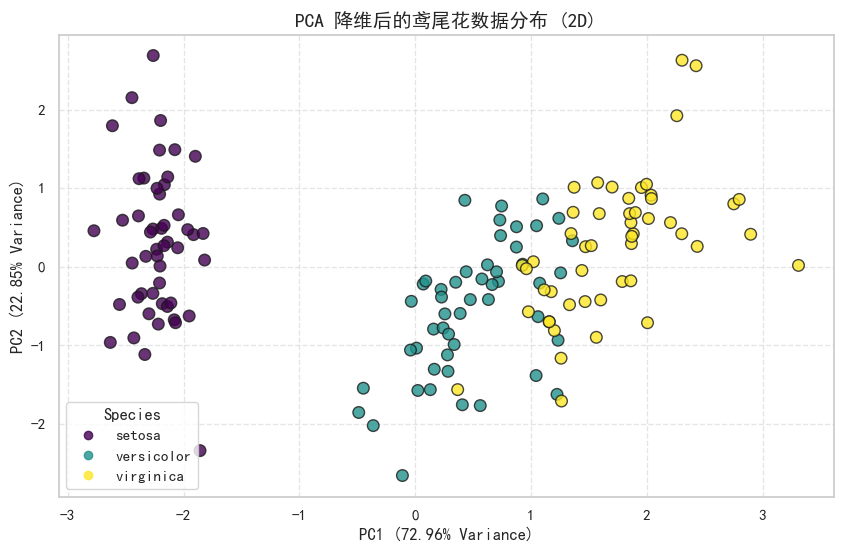

In [31]:
from sklearn.decomposition import PCA

# 重新加载完整数据
X_full = data.data
y_full = data.target

# 标准化 (PCA 前必须标准化)
X_full_scaled = StandardScaler().fit_transform(X_full)

# 使用 PCA 降维到 2 维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_full_scaled)

print(f"原始特征维度: {X_full.shape[1]}")
print(f"降维后特征维度: {X_pca.shape[1]}")
print(f"保留的方差比例: {pca.explained_variance_ratio_}")
print(f"总信息保留率: {sum(pca.explained_variance_ratio_):.2%}")

# 可视化降维后的数据
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_full, cmap='viridis', edgecolor='k', s=70, alpha=0.8)
plt.title('PCA 降维后的鸢尾花数据分布 (2D)', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} Variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} Variance)', fontsize=12)
plt.legend(handles=scatter.legend_elements()[0], labels=data.target_names.tolist(), title="Species")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 6. 进阶：效率提升 (KD-Tree)

当数据量较大时，传统的蛮力搜索 (Brute Force) 计算距离非常耗时。
KD-Tree 是一种对 k 维空间中的实例点进行存储以便对其进行快速检索的树形数据结构，可以显著提高 KNN 的搜索效率。

In [32]:
import time
from sklearn.datasets import make_classification

# 生成一个较大的模拟数据集 (10000 样本, 20 特征)
print("生成模拟数据集 (10000 样本, 20 特征)...")
X_large, y_large = make_classification(n_samples=10000, n_features=20, random_state=42)

# 1. Brute Force (蛮力搜索)
start_time = time.time()
knn_brute = KNeighborsClassifier(n_neighbors=5, algorithm='brute')
knn_brute.fit(X_large, y_large)
# 预测 1000 个样本
_ = knn_brute.predict(X_large[:1000])
time_brute = time.time() - start_time
print(f"Brute Force 耗时: {time_brute:.4f} 秒")

# 2. KD-Tree
start_time = time.time()
knn_kdtree = KNeighborsClassifier(n_neighbors=5, algorithm='kd_tree')
knn_kdtree.fit(X_large, y_large)
# 预测 1000 个样本
_ = knn_kdtree.predict(X_large[:1000])
time_kdtree = time.time() - start_time
print(f"KD-Tree 耗时: {time_kdtree:.4f} 秒")

print(f"KD-Tree 速度提升倍数: {time_brute / time_kdtree:.2f} 倍")

生成模拟数据集 (10000 样本, 20 特征)...
Brute Force 耗时: 0.0269 秒
KD-Tree 耗时: 0.2442 秒
KD-Tree 速度提升倍数: 0.11 倍


## 7. 进阶：样本不平衡处理 (随机过采样)

在实际应用中，各类别的样本数量往往不相等，这会导致模型偏向于多数类。
随机过采样 (Random Over-sampling) 是一种通过随机复制少数类样本来平衡数据集的方法。虽然不如 SMOTE 复杂，但在许多情况下也非常有效且不依赖额外的库。

原始不平衡数据集分布: Counter({1: 50, 2: 50, 0: 10})
过采样处理后数据集分布: Counter({1: 50, 2: 50, 0: 50})


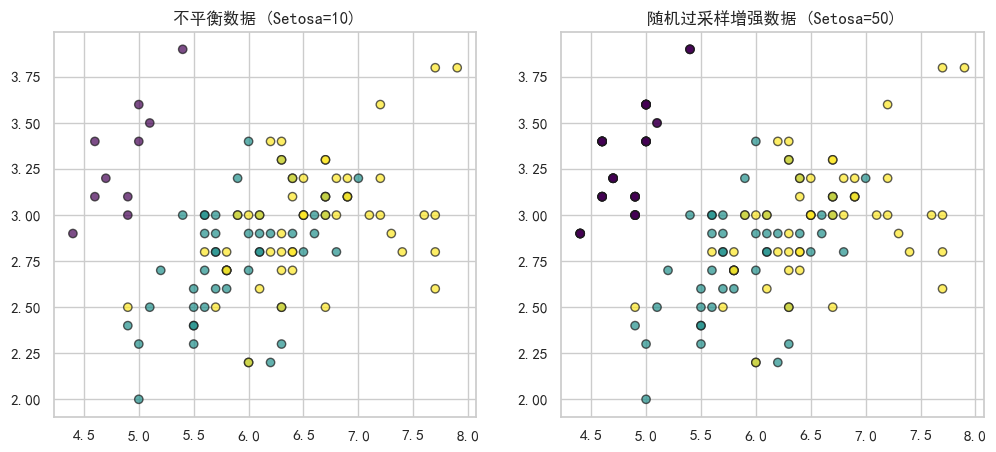

In [33]:
from sklearn.utils import resample
from collections import Counter

# 1. 构造一个不平衡的数据集
# 移除大部分 setosa (class 0) 样本，只保留前 10 个
# 原始数据: 50 setosa, 50 versicolor, 50 virginica
# 构造后: 10 setosa, 50 versicolor, 50 virginica
X_imb = np.concatenate([X_full[:10], X_full[50:]])
y_imb = np.concatenate([y_full[:10], y_full[50:]])

print("原始不平衡数据集分布:", Counter(y_imb))

# 2. 使用 sklearn.utils.resample 进行过采样
# 分离多数类和少数类
X_minority = X_imb[y_imb == 0]
y_minority = y_imb[y_imb == 0]
X_majority = X_imb[y_imb != 0]
y_majority = y_imb[y_imb != 0]

# 对少数类进行过采样，使其数量与多数类一致 (50)
X_minority_upsampled, y_minority_upsampled = resample(X_minority, y_minority,
                                                      replace=True,     # 允许重复采样
                                                      n_samples=50,    # 采样到 50 个样本
                                                      random_state=42) # 保证结果可复现

# 合并数据
X_res = np.vstack((X_majority, X_minority_upsampled))
y_res = np.hstack((y_majority, y_minority_upsampled))

print("过采样处理后数据集分布:", Counter(y_res))

# 3. 可视化对比 (取前两个特征)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_imb[:, 0], X_imb[:, 1], c=y_imb, cmap='viridis', edgecolor='k', alpha=0.7)
plt.title(f'不平衡数据 (Setosa={Counter(y_imb)[0]})')

plt.subplot(1, 2, 2)
plt.scatter(X_res[:, 0], X_res[:, 1], c=y_res, cmap='viridis', edgecolor='k', alpha=0.7)
plt.title(f'随机过采样增强数据 (Setosa={Counter(y_res)[0]})')

plt.show()